# CARACTERIZAMOS CADA SLOPE UNIT CON GEOLOGÍA Y COBERTURAS Y CON EL INVENTARIO DE MOVIMIENTOS EN MASA

# Caracterización de Slope Units con geología/tipo de suelo

Este notebook asigna a cada **slope unit** los atributos geológicos y geotécnicos de la capa `salida.shp`, utilizando el criterio de **mayoría de área de intersección**: a cada slope unit se le asigna la unidad geológica que cubre la mayor superficie dentro de ella.

**Columnas heredadas:** `Codigo`, `Unidad_geo`, `Granulomet`, `Espesor_m`, `Gamma_kNm3`, `C_kPa`, `Phi`.

**Salida:** un nuevo GeoPackage con todas las slope units enriquecidas con los atributos geológicos dominantes.

## 1. Importar librerías

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print(f"GeoPandas: {gpd.__version__}")
print(f"Pandas: {pd.__version__}")

GeoPandas: 0.13.2
Pandas: 2.0.3


## 2. Definir rutas de entrada y salida

In [2]:
# Rutas de entrada
slope_units_path = "/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_clusterizadas_todos.gpkg"
geologia_path = "/home/oisanchezp/Thesis/src/04_Chapter/geologia_alex/geologia_alex.gpkg"
geologia_layer = "suelos"

# Ruta de salida
output_dir = Path("/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado")
output_path = output_dir / "slope_units_caracterizadas.gpkg"
output_layer = "slope_units_caracterizadas"

# Columnas a heredar desde la capa de geología
COLS_HEREDAR = ["Codigo", "Unidad_geo", "Granulomet", "Espesor_m", "Gamma_kNm3", "C_kPa", "Phi"]

output_dir.mkdir(parents=True, exist_ok=True)
print(f"Slope units: {slope_units_path}")
print(f"Geología:    {geologia_path} (capa: {geologia_layer})")
print(f"Salida:      {output_path}")

Slope units: /home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_clusterizadas_todos.gpkg
Geología:    /home/oisanchezp/Thesis/src/04_Chapter/geologia_alex/geologia_alex.gpkg (capa: suelos)
Salida:      /home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_caracterizadas.gpkg


## 3. Cargar las capas

In [3]:
# Cargar slope units
slope_units = gpd.read_file(slope_units_path)
print(f"Slope units cargadas: {len(slope_units)} polígonos")
print(f"CRS: {slope_units.crs}")
print(f"Columnas: {list(slope_units.columns)}")
slope_units.head()

Slope units cargadas: 61242 polígonos
CRS: EPSG:3116
Columnas: ['Id', 'gridcode', 'Shape_Leng', 'Shape_Area', 'slope_mean', 'curva_mean', 'acos_mean', 'asin_mean', 'aspect_mea', 'area', 'su_type', 'cluster_prob', 'geometry']


,Id,gridcode,Shape_Leng,Shape_Area,slope_mean,curva_mean,acos_mean,asin_mean,aspect_mea,area,su_type,cluster_prob,geometry
0,3683,2978,724.443245,23009.556086,23.656450,0.003081,0.853198,0.206826,13.626339,0.003555,2,0.849376,"MULTIPOLYGON (((862736.779 1211959.991, 862736..."
1,4178,3888,441.842741,10463.388311,20.119491,-0.002061,-0.548672,0.750604,126.165838,0.010458,2,0.524279,"MULTIPOLYGON (((862916.264 1211961.269, 862917..."
2,4666,4314,478.805068,9837.858532,22.920414,-0.001765,-0.640250,0.614889,136.157556,0.002859,2,0.395056,"MULTIPOLYGON (((862731.079 1211900.499, 862734..."
3,4669,4315,602.184217,13182.718538,20.990250,0.000634,0.327328,0.770644,66.986857,0.008595,1,0.647544,"MULTIPOLYGON (((862934.093 1211984.615, 862934..."
4,5221,5115,533.482334,7543.447490,14.661900,-0.001002,0.515300,0.664819,52.220823,0.003925,1,0.945023,"MULTIPOLYGON (((862720.787 1211859.908, 862720..."


In [4]:
# Cargar geología
geologia = gpd.read_file(geologia_path, layer=geologia_layer)
print(f"Polígonos de geología cargados: {len(geologia)}")
print(f"CRS: {geologia.crs}")
print(f"Columnas: {list(geologia.columns)}")
geologia.head()

Polígonos de geología cargados: 74
CRS: PROJCS["MAGNA-SIRGAS_CMT12",GEOGCS["MAGNA-SIRGAS",DATUM["Marco_Geocentrico_Nacional_de_Referencia",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6686"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4686"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",4],PARAMETER["central_meridian",-73],PARAMETER["scale_factor",0.9992],PARAMETER["false_easting",5000000],PARAMETER["false_northing",2000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["ESRI","103599"]]
Columnas: ['Codigo', 'Unidad_geo', 'Granulomet', 'Espesor_m', 'Gamma_kNm3', 'C_kPa', 'Phi', 'Cat_modelo', 'Shape_Leng', 'Shape_Area', 'geometry']


,Codigo,Unidad_geo,Granulomet,Espesor_m,Gamma_kNm3,C_kPa,Phi,Cat_modelo,Shape_Leng,Shape_Area,geometry
0,Rmba,Roca muy blanda de anfibolitas,Limo arenoso,None,0.0,0.0,0.0,1,2.090791e+05,3.771129e+08,MULTIPOLYGON Z (((4713964.549 2269202.481 0.00...
1,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,2,1.411472e+06,4.316687e+09,MULTIPOLYGON Z (((4713964.167 2269202.727 0.00...
2,Sralba,"Suelo residual arenolimoso de granodioritas, t...",Arena limosa,None,13.3,14.6,17.0,2,1.301763e+05,1.103533e+06,MULTIPOLYGON Z (((4752802.095 2272753.709 0.00...
3,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,2,5.308942e+05,1.942919e+08,MULTIPOLYGON Z (((4729285.447 2269750.847 0.00...
4,Stco,Depósitos de flujos de escombros y/o lodos,"Bloques, gravas, arenas y lodos",None,0.0,0.0,0.0,4,6.482760e+05,6.747799e+07,MULTIPOLYGON Z (((4706547.020 2225015.317 0.00...


## 4. Validaciones previas

- Verificar que las columnas a heredar existan en la capa de geología.
- Homogeneizar CRS (reproyectar la geología al CRS de las slope units si difieren).
- Asegurar que el CRS sea proyectado (en metros) para que los cálculos de área sean correctos.

In [5]:
# Verificar columnas
cols_faltantes = [c for c in COLS_HEREDAR if c not in geologia.columns]
if cols_faltantes:
    print(f"⚠️  Columnas NO encontradas en la capa de geología: {cols_faltantes}")
    print(f"    Columnas disponibles: {list(geologia.columns)}")
else:
    print(f"✅ Todas las columnas a heredar están presentes: {COLS_HEREDAR}")

✅ Todas las columnas a heredar están presentes: ['Codigo', 'Unidad_geo', 'Granulomet', 'Espesor_m', 'Gamma_kNm3', 'C_kPa', 'Phi']


In [6]:
# Homogeneizar CRS
if slope_units.crs != geologia.crs:
    print(f"Reproyectando geología de {geologia.crs} → {slope_units.crs}")
    geologia = geologia.to_crs(slope_units.crs)
else:
    print(f"✅ Ambas capas comparten CRS: {slope_units.crs}")

# Advertencia si el CRS es geográfico (grados)
if slope_units.crs.is_geographic:
    print("⚠️  El CRS es geográfico (grados). Los cálculos de área no serán precisos.")
    print("    Se recomienda reproyectar a un CRS proyectado (p.ej. MAGNA-SIRGAS / Colombia Bogotá, EPSG:3116).")

Reproyectando geología de PROJCS["MAGNA-SIRGAS_CMT12",GEOGCS["MAGNA-SIRGAS",DATUM["Marco_Geocentrico_Nacional_de_Referencia",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6686"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4686"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",4],PARAMETER["central_meridian",-73],PARAMETER["scale_factor",0.9992],PARAMETER["false_easting",5000000],PARAMETER["false_northing",2000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["ESRI","103599"]] → EPSG:3116


In [7]:
# Limpiar geometrías inválidas para evitar errores en el overlay
def limpiar_geometrias(gdf, nombre):
    n_invalidas = (~gdf.geometry.is_valid).sum()
    if n_invalidas > 0:
        print(f"   {nombre}: corrigiendo {n_invalidas} geometrías inválidas con buffer(0)")
        gdf = gdf.copy()
        gdf['geometry'] = gdf.geometry.buffer(0)
    else:
        print(f"   {nombre}: todas las geometrías son válidas")
    return gdf

slope_units = limpiar_geometrias(slope_units, "slope_units")
geologia = limpiar_geometrias(geologia, "geologia")

   slope_units: todas las geometrías son válidas
   geologia: todas las geometrías son válidas


## 5. Identificador único para las slope units

Creamos un identificador interno `su_id` para trazabilidad durante el cruce espacial (no modifica los atributos originales).

In [8]:
slope_units = slope_units.reset_index(drop=True)
slope_units['su_id'] = slope_units.index.astype(int)
print(f"ID interno 'su_id' creado: {slope_units['su_id'].min()}–{slope_units['su_id'].max()}")

ID interno 'su_id' creado: 0–61241


## 6. Intersección espacial (overlay)

Se calcula la intersección entre cada slope unit y cada polígono de geología. Cada fragmento resultante tendrá el `su_id` de la slope unit y los atributos geológicos. Luego calculamos el área de cada fragmento.

In [9]:
# Subconjunto de geología con sólo las columnas necesarias (+ geometría)
cols_presentes = [c for c in COLS_HEREDAR if c in geologia.columns]
geologia_sub = geologia[cols_presentes + ['geometry']].copy()

# Overlay intersección
print("Calculando intersección espacial... (puede tardar unos segundos)")
interseccion = gpd.overlay(
    slope_units[['su_id', 'geometry']],
    geologia_sub,
    how='intersection',
    keep_geom_type=True
)
print(f"✅ Fragmentos de intersección: {len(interseccion)}")
interseccion.head()

Calculando intersección espacial... (puede tardar unos segundos)
✅ Fragmentos de intersección: 92234


,su_id,Codigo,Unidad_geo,Granulomet,Espesor_m,Gamma_kNm3,C_kPa,Phi,geometry
0,0,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,"POLYGON Z ((862736.753 1211966.316 0.000, 8627..."
1,1,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,"POLYGON Z ((862917.949 1211949.856 0.000, 8629..."
2,2,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,"POLYGON Z ((862735.682 1211928.995 0.000, 8627..."
3,3,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,"POLYGON Z ((862934.115 1211984.612 0.000, 8629..."
4,4,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,"POLYGON Z ((862720.788 1211859.918 0.000, 8627..."


In [10]:
# Calcular área de cada fragmento (m² si el CRS es proyectado)
interseccion['area_int'] = interseccion.geometry.area
print(f"Área total intersectada: {interseccion['area_int'].sum():,.2f} m²")
print(f"Área mínima de fragmento: {interseccion['area_int'].min():,.4f} m²")
print(f"Área máxima de fragmento: {interseccion['area_int'].max():,.2f} m²")

Área total intersectada: 1,006,977,330.92 m²
Área mínima de fragmento: 0.0000 m²
Área máxima de fragmento: 162,693.00 m²


## 7. Asignar la geología dominante a cada slope unit

Por cada `su_id`, se selecciona el fragmento con mayor área. Los atributos de ese fragmento son los que hereda la slope unit.

In [11]:
# Índice del fragmento con mayor área por slope unit
idx_max = interseccion.groupby('su_id')['area_int'].idxmax()

# Atributos dominantes (sin geometría)
dominante = (
    interseccion.loc[idx_max, ['su_id'] + cols_presentes + ['area_int']]
    .rename(columns={'area_int': 'area_dominante_m2'})
    .reset_index(drop=True)
)

print(f"Slope units con geología asignada: {len(dominante)} / {len(slope_units)}")
dominante.head()

Slope units con geología asignada: 61242 / 61242


,su_id,Codigo,Unidad_geo,Granulomet,Espesor_m,Gamma_kNm3,C_kPa,Phi,area_dominante_m2
0,0,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,3556.823914
1,1,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,8761.201687
2,2,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,2657.875879
3,3,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,8283.177091
4,4,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,3191.292360


In [12]:
# También calculamos el porcentaje de área que cubre la geología dominante dentro de cada SU
area_total_su = interseccion.groupby('su_id')['area_int'].sum().rename('area_total_su_m2')
dominante = dominante.merge(area_total_su, on='su_id', how='left')
dominante['pct_dominante'] = 100 * dominante['area_dominante_m2'] / dominante['area_total_su_m2']

print("Distribución del porcentaje de área cubierto por la geología dominante:")
print(dominante['pct_dominante'].describe().round(2))

Distribución del porcentaje de área cubierto por la geología dominante:
count    61242.00
mean        92.68
std         13.75
min         26.66
25%         92.41
50%        100.00
75%        100.00
max        100.00
Name: pct_dominante, dtype: float64


## 8. Unir los atributos dominantes a las slope units originales

In [13]:
slope_units_carac = slope_units.merge(dominante, on='su_id', how='left')

# Diagnóstico: slope units que no intersectan ninguna geología
sin_geologia = slope_units_carac[slope_units_carac['Codigo'].isna()] if 'Codigo' in slope_units_carac.columns else pd.DataFrame()
print(f"Slope units sin geología asignada: {len(sin_geologia)}")
if len(sin_geologia) > 0:
    print("   (probablemente caen fuera de la capa de geología)")

print(f"\nDimensiones finales: {slope_units_carac.shape}")
print(f"Columnas finales: {list(slope_units_carac.columns)}")
slope_units_carac.head()

Slope units sin geología asignada: 0

Dimensiones finales: (61242, 24)
Columnas finales: ['Id', 'gridcode', 'Shape_Leng', 'Shape_Area', 'slope_mean', 'curva_mean', 'acos_mean', 'asin_mean', 'aspect_mea', 'area', 'su_type', 'cluster_prob', 'geometry', 'su_id', 'Codigo', 'Unidad_geo', 'Granulomet', 'Espesor_m', 'Gamma_kNm3', 'C_kPa', 'Phi', 'area_dominante_m2', 'area_total_su_m2', 'pct_dominante']


,Id,gridcode,Shape_Leng,Shape_Area,slope_mean,curva_mean,acos_mean,asin_mean,aspect_mea,area,...,Codigo,Unidad_geo,Granulomet,Espesor_m,Gamma_kNm3,C_kPa,Phi,area_dominante_m2,area_total_su_m2,pct_dominante
0,3683,2978,724.443245,23009.556086,23.656450,0.003081,0.853198,0.206826,13.626339,0.003555,...,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,3556.823914,3556.823914,100.000000
1,4178,3888,441.842741,10463.388311,20.119491,-0.002061,-0.548672,0.750604,126.165838,0.010458,...,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,8761.201687,11186.881530,78.316747
2,4666,4314,478.805068,9837.858532,22.920414,-0.001765,-0.640250,0.614889,136.157556,0.002859,...,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,2657.875879,2860.303599,92.922859
3,4669,4315,602.184217,13182.718538,20.990250,0.000634,0.327328,0.770644,66.986857,0.008595,...,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,8283.177091,8843.106807,93.668179
4,5221,5115,533.482334,7543.447490,14.661900,-0.001002,0.515300,0.664819,52.220823,0.003925,...,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,3191.292360,3926.776947,81.270019


## 9. Resumen por unidad geológica

In [14]:
if 'Unidad_geo' in slope_units_carac.columns:
    resumen = (
        slope_units_carac.groupby('Unidad_geo')
        .agg(n_slope_units=('su_id', 'count'),
             pct_dominante_media=('pct_dominante', 'mean'))
        .sort_values('n_slope_units', ascending=False)
        .round(2)
    )
    print(resumen)

                                                    n_slope_units  \
Unidad_geo                                                          
Suelo residual arenoarcilloso de cuarzodioritas...          11790   
Roca muy blanda de anfibolitas                               9076   
Depósitos de flujos de escombros y/o lodos                   8185   
Roca blanda de esquistos cuarzomoscovíticos, cl...           6547   
Suelo residual limoarcilloso de diabasas y basa...           4960   
Suelo residual arenoarcilloso de granodioritas,...           4616   
Suelo residual limoarcilloso de la Dunita de Me...           3158   
Suelo residual arenolimoso de granodioritas, to...           2926   
Roca muy blanda de esquistos cuarzosericíticos,...           1630   
Suelo residual limoarenoso de los Gabros de Rom...            900   
Roca blanda de granodioritas, cuarzomonzonitas ...            755   
Suelo residual arenolimoso de gneises cuarzofel...            730   
Roca intermedia de esquistos cuarz

## 10. Guardar resultado como GeoPackage

In [15]:
# Opcional: eliminar columnas auxiliares si no las necesitas en el archivo final
# (comenta esta línea si quieres conservar su_id, area_dominante_m2, etc.)
# slope_units_carac = slope_units_carac.drop(columns=['su_id'])

slope_units_carac.to_file(output_path, layer=output_layer, driver='GPKG')
print(f"✅ GeoPackage guardado en:\n   {output_path}")
print(f"   Capa: {output_layer}")
print(f"   Registros: {len(slope_units_carac)}")

✅ GeoPackage guardado en:
   /home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_caracterizadas.gpkg
   Capa: slope_units_caracterizadas
   Registros: 61242


## 11. Verificación rápida abriendo el archivo guardado

In [16]:
verif = gpd.read_file(output_path, layer=output_layer)
print(f"Registros: {len(verif)}")
print(f"CRS: {verif.crs}")
print(f"Columnas: {list(verif.columns)}")
verif[['su_id'] + [c for c in COLS_HEREDAR if c in verif.columns] + ['pct_dominante']].head(10)

Registros: 61242
CRS: EPSG:3116
Columnas: ['Id', 'gridcode', 'Shape_Leng', 'Shape_Area', 'slope_mean', 'curva_mean', 'acos_mean', 'asin_mean', 'aspect_mea', 'area', 'su_type', 'cluster_prob', 'su_id', 'Codigo', 'Unidad_geo', 'Granulomet', 'Espesor_m', 'Gamma_kNm3', 'C_kPa', 'Phi', 'area_dominante_m2', 'area_total_su_m2', 'pct_dominante', 'geometry']


,su_id,Codigo,Unidad_geo,Granulomet,Espesor_m,Gamma_kNm3,C_kPa,Phi,pct_dominante
0,0,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,100.000000
1,1,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,78.316747
2,2,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,92.922859
3,3,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,93.668179
4,4,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,81.270019
5,5,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,58.781884
6,6,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,64.796883
7,7,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,91.864397
8,8,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,88.440300
9,9,Sracgba,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,98.225773


## 12. (Opcional) Visualización rápida

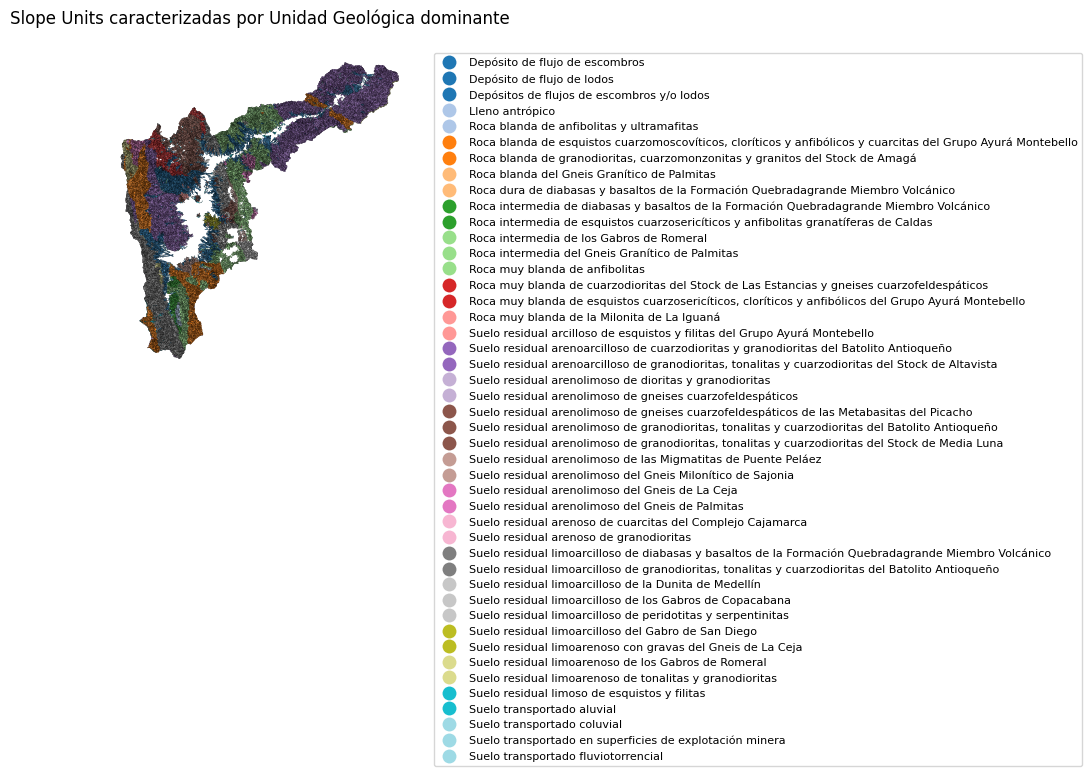

In [17]:
import matplotlib.pyplot as plt

if 'Unidad_geo' in slope_units_carac.columns:
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    slope_units_carac.plot(
        column='Unidad_geo',
        ax=ax,
        legend=True,
        cmap='tab20',
        edgecolor='black',
        linewidth=0.1,
        legend_kwds={'bbox_to_anchor': (1.05, 1), 'loc': 'upper left', 'fontsize': 8}
    )
    ax.set_title('Slope Units caracterizadas por Unidad Geológica dominante')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

# Asignar cobertura y uso del suelo a las Slope Units

Este notebook toma las slope units ya caracterizadas geológicamente (`slope_units_caracterizadas.gpkg`) y les asigna una nueva columna `cobertura` a partir del raster de cobertura y usos del suelo de SIATA.

**Criterio:** para cada slope unit se cuenta cuántos píxeles de cada categoría (0–5) caen dentro del polígono y se asigna la **categoría más frecuente (moda zonal)**.

**Entradas:**
- `slope_units_caracterizadas.gpkg` (salida del notebook anterior).
- `ClassValleH_120125.tif` (raster categórico, 6 clases: 0–5).

**Salida:** nuevo GeoPackage con la columna `cobertura` añadida.

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio
from rasterstats import zonal_stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print(f"GeoPandas:   {gpd.__version__}")
print(f"Rasterio:    {rasterio.__version__}")

GeoPandas:   0.13.2
Rasterio:    1.3.10


## 2. Rutas de entrada y salida

In [2]:
# Entradas
slope_units_path = "/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_caracterizadas.gpkg"
#slope_units_path = "/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_final.gpkg"
slope_units_layer = "slope_units_caracterizadas"
#slope_units_layer = "slope_units_final"
raster_path = "/home/oisanchezp/Thesis/src/04_Chapter/cobertura_siata/ClassValleH_120125.tif"

# Salida
output_dir = Path("/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado")
#output_path = output_dir / "slope_units_caracterizadas_cobertura.gpkg"
output_path = output_dir / "slope_units_final.gpkg"
#output_layer = "slope_units_caracterizadas_cobertura"
output_layer = "slope_units_final"

# Diccionario de categorías (edítalo según la leyenda de SIATA).
# Si lo dejas vacío, la columna 'cobertura' será numérica (0–5).
CATEGORIAS_COBERTURA = {
    0: "Tejido urbano continuo",
    1: "Tejido urbano discontinuo",
    2: "Territorios agrícolas",
    3: "Bosques",
    4: "Aguas continentales",
    5: "Tierras desnudas y degradadas",
}

output_dir.mkdir(parents=True, exist_ok=True)
print(f"Slope units: {slope_units_path}")
print(f"Raster:      {raster_path}")
print(f"Salida:      {output_path}")

Slope units: /home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_caracterizadas.gpkg
Raster:      /home/oisanchezp/Thesis/src/04_Chapter/cobertura_siata/ClassValleH_120125.tif
Salida:      /home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_final.gpkg


## 3. Cargar slope units caracterizadas

In [3]:
slope_units = gpd.read_file(slope_units_path, layer=slope_units_layer)
print(f"Slope units: {len(slope_units)}")
print(f"CRS: {slope_units.crs}")
print(f"Columnas: {list(slope_units.columns)}")
slope_units.head()

Slope units: 61242
CRS: EPSG:3116
Columnas: ['Id', 'gridcode', 'Shape_Leng', 'Shape_Area', 'slope_mean', 'curva_mean', 'acos_mean', 'asin_mean', 'aspect_mea', 'area', 'su_type', 'cluster_prob', 'su_id', 'Codigo', 'Unidad_geo', 'Granulomet', 'Espesor_m', 'Gamma_kNm3', 'C_kPa', 'Phi', 'area_dominante_m2', 'area_total_su_m2', 'pct_dominante', 'geometry']


,Id,gridcode,Shape_Leng,Shape_Area,slope_mean,curva_mean,acos_mean,asin_mean,aspect_mea,area,...,Unidad_geo,Granulomet,Espesor_m,Gamma_kNm3,C_kPa,Phi,area_dominante_m2,area_total_su_m2,pct_dominante,geometry
0,3683,2978,724.443245,23009.556086,23.656450,0.003081,0.853198,0.206826,13.626339,0.003555,...,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,3556.823914,3556.823914,100.000000,"MULTIPOLYGON (((862736.779 1211959.991, 862736..."
1,4178,3888,441.842741,10463.388311,20.119491,-0.002061,-0.548672,0.750604,126.165838,0.010458,...,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,8761.201687,11186.881530,78.316747,"MULTIPOLYGON (((862916.264 1211961.269, 862917..."
2,4666,4314,478.805068,9837.858532,22.920414,-0.001765,-0.640250,0.614889,136.157556,0.002859,...,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,2657.875879,2860.303599,92.922859,"MULTIPOLYGON (((862731.079 1211900.499, 862734..."
3,4669,4315,602.184217,13182.718538,20.990250,0.000634,0.327328,0.770644,66.986857,0.008595,...,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,8283.177091,8843.106807,93.668179,"MULTIPOLYGON (((862934.093 1211984.615, 862934..."
4,5221,5115,533.482334,7543.447490,14.661900,-0.001002,0.515300,0.664819,52.220823,0.003925,...,Suelo residual arenoarcilloso de cuarzodiorita...,Arena arcillosa,None,0.0,0.0,0.0,3191.292360,3926.776947,81.270019,"MULTIPOLYGON (((862720.787 1211859.908, 862720..."


## 4. Inspeccionar el raster de cobertura

In [4]:
with rasterio.open(raster_path) as src:
    raster_crs = src.crs
    raster_bounds = src.bounds
    raster_transform = src.transform
    raster_nodata = src.nodata
    raster_dtype = src.dtypes[0]
    raster_shape = (src.height, src.width)
    pixel_size = (src.transform.a, -src.transform.e)

    # Lectura rápida para histograma
    banda = src.read(1)

print(f"CRS raster:     {raster_crs}")
print(f"Dimensiones:    {raster_shape} (filas, columnas)")
print(f"Tamaño píxel:   {pixel_size} (unidades del CRS)")
print(f"Bounds:         {raster_bounds}")
print(f"Dtype:          {raster_dtype}")
print(f"NoData:         {raster_nodata}")

# Histograma global de categorías
valores, conteos = np.unique(banda, return_counts=True)
print("\nHistograma global (todo el raster):")
for v, c in zip(valores, conteos):
    print(f"  Categoría {v}: {c:,} píxeles")

CRS raster:     EPSG:32618
Dimensiones:    (6530, 6514) (filas, columnas)
Tamaño píxel:   (9.933711956966176, 9.933711956966176) (unidades del CRS)
Bounds:         BoundingBox(left=420374.2575097806, bottom=660789.486556399, right=485082.45719745825, top=725656.6256353882)
Dtype:          uint8
NoData:         255.0

Histograma global (todo el raster):
  Categoría 0: 1,552,653 píxeles
  Categoría 1: 2,713,315 píxeles
  Categoría 2: 4,078,260 píxeles
  Categoría 3: 5,412,530 píxeles
  Categoría 4: 35,977 píxeles
  Categoría 5: 124,805 píxeles
  Categoría 255: 28,618,880 píxeles


## 5. Homogeneizar CRS

`rasterstats` requiere que los polígonos estén en el mismo CRS del raster. Si difieren, reproyectamos las slope units (no el raster, para no remuestrear la capa categórica).

In [5]:
if slope_units.crs != raster_crs:
    print(f"Reproyectando slope units de {slope_units.crs} → {raster_crs}")
    slope_units_rep = slope_units.to_crs(raster_crs)
else:
    print(f"✅ CRS coincidentes: {raster_crs}")
    slope_units_rep = slope_units.copy()

Reproyectando slope units de EPSG:3116 → EPSG:32618


## 6. Estadística zonal categórica

`zonal_stats(..., categorical=True)` devuelve por cada polígono un diccionario `{categoria: n_pixeles}`. De ahí sacamos la **moda** (categoría con más píxeles).

In [6]:
print("Calculando estadística zonal categórica... (puede tardar)")
stats = zonal_stats(
    slope_units_rep,
    raster_path,
    categorical=True,
    nodata=raster_nodata,
    all_touched=False,   # True si quieres incluir píxeles tocados por el borde del polígono
    geojson_out=False
)
print(f"✅ Resultados: {len(stats)} slope units procesadas")
print(f"\nEjemplo (primeras 3 slope units):")
for i, s in enumerate(stats[:3]):
    print(f"  SU {i}: {s}")

Calculando estadística zonal categórica... (puede tardar)
✅ Resultados: 61242 slope units procesadas

Ejemplo (primeras 3 slope units):
  SU 0: {2: 36}
  SU 1: {2: 114}
  SU 2: {2: 29}


## 7. Extraer moda, porcentaje y conteo total de píxeles

In [7]:
def resumen_cobertura(conteo_dict):
    """Dado un diccionario {categoria: n_pixeles}, devuelve moda, n_pixeles moda, total, %."""
    if not conteo_dict:
        return pd.Series({
            'cobertura_cat': np.nan,
            'n_pix_dominante': 0,
            'n_pix_total': 0,
            'pct_cobertura_dominante': np.nan
        })
    # Filtrar posibles NaN como llave
    limpio = {int(k): int(v) for k, v in conteo_dict.items() if pd.notna(k)}
    if not limpio:
        return pd.Series({
            'cobertura_cat': np.nan,
            'n_pix_dominante': 0,
            'n_pix_total': 0,
            'pct_cobertura_dominante': np.nan
        })
    moda = max(limpio, key=limpio.get)
    n_mod = limpio[moda]
    total = sum(limpio.values())
    return pd.Series({
        'cobertura_cat': int(moda),
        'n_pix_dominante': n_mod,
        'n_pix_total': total,
        'pct_cobertura_dominante': round(100 * n_mod / total, 2) if total > 0 else np.nan
    })

df_cob = pd.DataFrame([resumen_cobertura(s) for s in stats])
df_cob.head()

,cobertura_cat,n_pix_dominante,n_pix_total,pct_cobertura_dominante
0,2.0,36.0,36.0,100.0
1,2.0,114.0,114.0,100.0
2,2.0,29.0,29.0,100.0
3,2.0,87.0,87.0,100.0
4,2.0,41.0,41.0,100.0


In [8]:
# Diagnóstico
sin_pixeles = (df_cob['n_pix_total'] == 0).sum()
print(f"Slope units sin píxeles dentro: {sin_pixeles}")
if sin_pixeles > 0:
    print("   (polígonos muy pequeños respecto al tamaño de pixel o fuera del raster).")
    print("   Puedes reintentar el paso 6 con `all_touched=True` para incluir píxeles de borde.")

print("\nDistribución de la categoría dominante:")
print(df_cob['cobertura_cat'].value_counts(dropna=False).sort_index())

Slope units sin píxeles dentro: 247
   (polígonos muy pequeños respecto al tamaño de pixel o fuera del raster).
   Puedes reintentar el paso 6 con `all_touched=True` para incluir píxeles de borde.

Distribución de la categoría dominante:
cobertura_cat
0.0     3744
1.0    11824
2.0    17770
3.0    27190
4.0       30
5.0      437
NaN      247
Name: count, dtype: int64


## 8. Añadir la columna `cobertura` a las slope units

Mantenemos la categoría numérica en `cobertura_cat` y creamos `cobertura` como el nombre legible (según `CATEGORIAS_COBERTURA`).

In [9]:
# Unir por índice posicional (mismo orden que slope_units_rep)
slope_units_cob = slope_units.reset_index(drop=True).copy()
slope_units_cob = pd.concat([slope_units_cob, df_cob.reset_index(drop=True)], axis=1)

# Columna 'cobertura' como etiqueta (o numérica si no se definió el diccionario)
if CATEGORIAS_COBERTURA:
    slope_units_cob['cobertura'] = slope_units_cob['cobertura_cat'].map(CATEGORIAS_COBERTURA)
else:
    slope_units_cob['cobertura'] = slope_units_cob['cobertura_cat']

# Re-asegurar GeoDataFrame
slope_units_cob = gpd.GeoDataFrame(slope_units_cob, geometry='geometry', crs=slope_units.crs)

print(f"Dimensiones finales: {slope_units_cob.shape}")
print(f"Columnas nuevas: cobertura_cat, cobertura, n_pix_dominante, n_pix_total, pct_cobertura_dominante")
slope_units_cob[['su_id', 'cobertura_cat', 'cobertura', 'pct_cobertura_dominante']].head(10)

Dimensiones finales: (61242, 29)
Columnas nuevas: cobertura_cat, cobertura, n_pix_dominante, n_pix_total, pct_cobertura_dominante


,su_id,cobertura_cat,cobertura,pct_cobertura_dominante
0,0,2.0,Territorios agrícolas,100.0
1,1,2.0,Territorios agrícolas,100.0
2,2,2.0,Territorios agrícolas,100.0
3,3,2.0,Territorios agrícolas,100.0
4,4,2.0,Territorios agrícolas,100.0
5,5,2.0,Territorios agrícolas,100.0
6,6,2.0,Territorios agrícolas,100.0
7,7,2.0,Territorios agrícolas,100.0
8,8,2.0,Territorios agrícolas,100.0
9,9,2.0,Territorios agrícolas,100.0


## 9. Resumen cruzado: geología × cobertura

In [10]:
print("Slope units por categoría de cobertura:")
print(slope_units_cob['cobertura'].value_counts(dropna=False))

if 'Unidad_geo' in slope_units_cob.columns:
    print("\nTabla cruzada Unidad_geo × cobertura:")
    tabla = pd.crosstab(slope_units_cob['Unidad_geo'], slope_units_cob['cobertura'], margins=True)
    print(tabla)

Slope units por categoría de cobertura:
cobertura
Bosques                          27190
Territorios agrícolas            17770
Tejido urbano discontinuo        11824
Tejido urbano continuo            3744
Tierras desnudas y degradadas      437
NaN                                247
Aguas continentales                 30
Name: count, dtype: int64

Tabla cruzada Unidad_geo × cobertura:
cobertura                                           Aguas continentales  \
Unidad_geo                                                                
Depósito de flujo de escombros                                        0   
Depósito de flujo de lodos                                            0   
Depósitos de flujos de escombros y/o lodos                            2   
Lleno antrópico                                                       1   
Roca blanda de anfibolitas y ultramafitas                             0   
Roca blanda de esquistos cuarzomoscovíticos, cl...                    1   
Roca blanda 

## 10. Guardar GeoPackage final

In [11]:
slope_units_cob.to_file(output_path, layer=output_layer, driver='GPKG')
print(f"✅ Guardado en:\n   {output_path}")
print(f"   Capa: {output_layer}")
print(f"   Registros: {len(slope_units_cob)}")

✅ Guardado en:
   /home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_final.gpkg
   Capa: slope_units_final
   Registros: 61242


## 11. Verificación

In [12]:
verif = gpd.read_file(output_path, layer=output_layer)
print(f"Registros: {len(verif)}")
print(f"CRS: {verif.crs}")
print(f"Columnas: {list(verif.columns)}")
verif[['su_id', 'Unidad_geo', 'cobertura_cat', 'cobertura', 'pct_cobertura_dominante']].head(10)

Registros: 61242
CRS: EPSG:3116
Columnas: ['Id', 'gridcode', 'Shape_Leng', 'Shape_Area', 'slope_mean', 'curva_mean', 'acos_mean', 'asin_mean', 'aspect_mea', 'area', 'su_type', 'cluster_prob', 'su_id', 'Codigo', 'Unidad_geo', 'Granulomet', 'Espesor_m', 'Gamma_kNm3', 'C_kPa', 'Phi', 'area_dominante_m2', 'area_total_su_m2', 'pct_dominante', 'cobertura_cat', 'n_pix_dominante', 'n_pix_total', 'pct_cobertura_dominante', 'cobertura', 'geometry']


,su_id,Unidad_geo,cobertura_cat,cobertura,pct_cobertura_dominante
0,0,Suelo residual arenoarcilloso de cuarzodiorita...,2.0,Territorios agrícolas,100.0
1,1,Suelo residual arenoarcilloso de cuarzodiorita...,2.0,Territorios agrícolas,100.0
2,2,Suelo residual arenoarcilloso de cuarzodiorita...,2.0,Territorios agrícolas,100.0
3,3,Suelo residual arenoarcilloso de cuarzodiorita...,2.0,Territorios agrícolas,100.0
4,4,Suelo residual arenoarcilloso de cuarzodiorita...,2.0,Territorios agrícolas,100.0
5,5,Suelo residual arenoarcilloso de cuarzodiorita...,2.0,Territorios agrícolas,100.0
6,6,Suelo residual arenoarcilloso de cuarzodiorita...,2.0,Territorios agrícolas,100.0
7,7,Suelo residual arenoarcilloso de cuarzodiorita...,2.0,Territorios agrícolas,100.0
8,8,Suelo residual arenoarcilloso de cuarzodiorita...,2.0,Territorios agrícolas,100.0
9,9,Suelo residual arenoarcilloso de cuarzodiorita...,2.0,Territorios agrícolas,100.0


## 12. (Opcional) Visualización

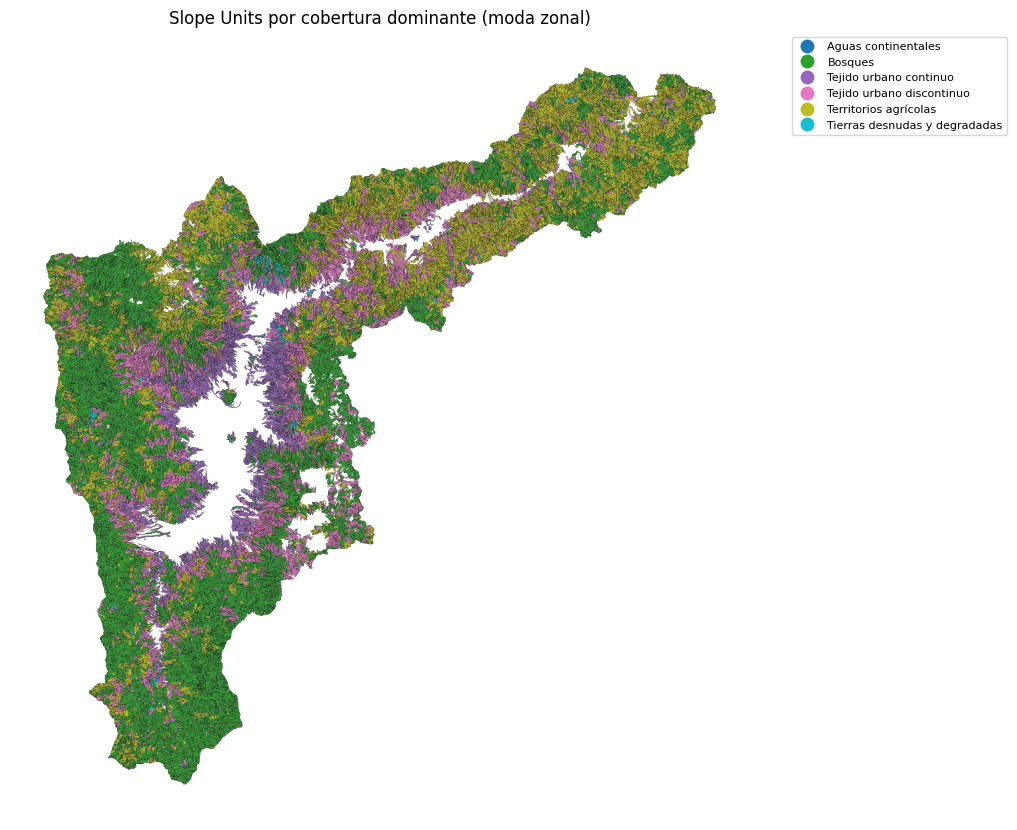

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
slope_units_cob.plot(
    column='cobertura',
    ax=ax,
    legend=True,
    cmap='tab10',
    edgecolor='black',
    linewidth=0.1,
    legend_kwds={'bbox_to_anchor': (1.05, 1), 'loc': 'upper left', 'fontsize': 8}
)
ax.set_title('Slope Units por cobertura dominante (moda zonal)')
ax.set_axis_off()
plt.tight_layout()
plt.show()

# Recodificación de la variable `cobertura` en las Slope Units

**Objetivo.** Dejar la variable de cobertura del suelo lista para entrar al modelo de susceptibilidad, con dos transformaciones:

1. **Renombrar** las etiquetas `Clase_0 … Clase_5` por nombres legibles (CLC).
2. **Reasignar** la clase `4 = Aguas continentales` a `1 = Tejido urbano discontinuo`, porque por su escasez (30 polígonos) y por no ser una superficie deslizable, no aporta señal al modelo. Tras esa fusión se renumera la clase `5 = Tierras desnudas y degradadas` a `4`, dejando un dominio limpio `{0,1,2,3,4}`.

Los `NaN` se preservan en ambos pasos (no se imputan).

**Insumo.** `slope_units_final.gpkg`, capa `slope_units_final` (61.242 SU).  
**Salida.** `slope_units_cobertura_recodificada.gpkg`, misma capa, columnas `cobertura` y `cobertura_cat` actualizadas.

## 1. Imports y configuración

In [ ]:
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd

#INPUT_PATH  = Path('slope_units_final.gpkg')
INPUT_PATH  = "/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_final.gpkg"
INPUT_LAYER = 'slope_units_final'

OUTPUT_PATH  = "/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_cobertura_recodificada.gpkg"
OUTPUT_LAYER = 'slope_units_final'

COL_STR = 'cobertura'      # string: 'Clase_0', ..., 'Clase_5', NaN
COL_NUM = 'cobertura_cat'  # numérica: 0..5, NaN

## 2. Carga del GeoPackage e inspección inicial

Verificamos CRS, tamaño y distribuciones para tener un *baseline* contra el cual validar después.

In [ ]:
gdf = gpd.read_file(INPUT_PATH, layer=INPUT_LAYER)

print(f'Filas        : {len(gdf):,}')
print(f'CRS          : {gdf.crs}')
print(f'Geometría    : {gdf.geom_type.unique()}')
print(f'Columnas     : {gdf.columns.tolist()}')

Filas        : 61,242
CRS          : EPSG:3116
Geometría    : ['MultiPolygon']
Columnas     : ['Id', 'gridcode', 'Shape_Leng', 'Shape_Area', 'slope_mean', 'curva_mean', 'acos_mean', 'asin_mean', 'aspect_mea', 'area', 'su_type', 'cluster_prob', 'su_id', 'Codigo', 'Unidad_geo', 'Granulomet', 'Espesor_m', 'Gamma_kNm3', 'C_kPa', 'Phi', 'area_dominante_m2', 'area_total_su_m2', 'pct_dominante', 'cobertura_cat', 'n_pix_dominante', 'n_pix_total', 'pct_cobertura_dominante', 'cobertura', 'geometry']


In [ ]:
def resumen_cobertura(gdf, col_str=COL_STR, col_num=COL_NUM):
    """Devuelve una tabla con conteos cruzados de las dos columnas de cobertura.

    Útil para validar consistencia entre la versión textual y la numérica
    antes y después de cada transformación.
    """
    tabla = (
        gdf[[col_num, col_str]]
        .value_counts(dropna=False)
        .rename('n')
        .reset_index()
        .sort_values(col_num, na_position='last')
        .reset_index(drop=True)
    )
    return tabla

print('--- Estado inicial: pares (cobertura_cat, cobertura) ---')
resumen_cobertura(gdf)

--- Estado inicial: pares (cobertura_cat, cobertura) ---


,cobertura_cat,cobertura,n
0,0.0,Tejido urbano continuo,3744
1,1.0,Tejido urbano discontinuo,11824
2,2.0,Territorios agrícolas,17770
3,3.0,Bosques,27190
4,4.0,Aguas continentales,30
5,5.0,Tierras desnudas y degradadas,437
6,NaN,NaN,247


## 3. Diccionarios de mapeo

Centralizamos las equivalencias en diccionarios para que la lógica sea **explícita, auditable y reproducible**.

- `MAPEO_CLASE_A_NOMBRE`: traducción literal `Clase_X` → nombre CLC.
- `MAPEO_REASIGNACION_NUM`: regla de fusión y renumeración (`4 → 1`, `5 → 4`).
- `MAPEO_COD_FINAL_A_NOMBRE`: codificación final tras la reasignación.

In [ ]:
MAPEO_CLASE_A_NOMBRE = {
    'Tejido urbano continuo': 'Tejido urbano continuo',
    'Tejido urbano discontinuo': 'Tejido urbano discontinuo',
    'Territorios agrícolas': 'Territorios agrícolas',
    'Bosques': 'Bosques',
    'Aguas continentales': 'Aguas continentales',
    'Tierras desnudas y degradadas': 'Tierras desnudas y degradadas',
}

MAPEO_REASIGNACION_NUM = {
    0: 0,  # Tejido urbano continuo            -> sin cambio
    1: 1,  # Tejido urbano discontinuo         -> sin cambio
    2: 2,  # Territorios agrícolas             -> sin cambio
    3: 3,  # Bosques                           -> sin cambio
    4: 1,  # Aguas continentales               -> Tejido urbano discontinuo (fusión)
    5: 4,  # Tierras desnudas y degradadas     -> renumeración (5 -> 4)
}

MAPEO_COD_FINAL_A_NOMBRE = {
    0: 'Tejido urbano continuo',
    1: 'Tejido urbano discontinuo',
    2: 'Territorios agrícolas',
    3: 'Bosques',
    4: 'Tierras desnudas y degradadas',
}

## 4. Paso 1 — Renombrar `Clase_X` por nombres legibles

Cambia únicamente la columna `cobertura` (string). El método `Series.map` con un diccionario asigna `NaN` a cualquier valor no listado, pero como aquí cubrimos todas las clases existentes, el único `NaN` resultante son los `NaN` originales, que se preservan.

In [ ]:
def renombrar_clases(
    gdf: gpd.GeoDataFrame,
    mapeo: dict,
    col_str: str = COL_STR,
) -> gpd.GeoDataFrame:
    """Renombra los valores `Clase_X` de la columna textual por nombres legibles.

    Parameters
    ----------
    gdf : GeoDataFrame de entrada (no se modifica in-place).
    mapeo : dict con la equivalencia 'Clase_X' -> nombre.
    col_str : nombre de la columna textual de cobertura.

    Returns
    -------
    GeoDataFrame con la columna `col_str` renombrada y los NaN preservados.
    """
    out = gdf.copy()

    # Validación: ¿hay valores no contemplados (ni NaN ni en el mapeo)?
    valores = out[col_str].dropna().unique()
    no_mapeados = [v for v in valores if v not in mapeo]
    if no_mapeados:
        raise ValueError(
            f'Valores no contemplados en {col_str}: {no_mapeados}. '
            f'Revisar el diccionario MAPEO_CLASE_A_NOMBRE.'
        )

    # map() preserva NaN de forma natural
    out[col_str] = out[col_str].map(mapeo).astype('object')
    return out


gdf_p1 = renombrar_clases(gdf, MAPEO_CLASE_A_NOMBRE)

print('--- Tras Paso 1: cobertura (string) renombrada ---')
resumen_cobertura(gdf_p1)

--- Tras Paso 1: cobertura (string) renombrada ---


,cobertura_cat,cobertura,n
0,0.0,Tejido urbano continuo,3744
1,1.0,Tejido urbano discontinuo,11824
2,2.0,Territorios agrícolas,17770
3,3.0,Bosques,27190
4,4.0,Aguas continentales,30
5,5.0,Tierras desnudas y degradadas,437
6,NaN,NaN,247


## 5. Paso 2 — Reasignar la columna numérica y sincronizar la textual

**Decisión justificada.** La clase `4 = Aguas continentales` se fusiona con `1 = Tejido urbano discontinuo` por dos razones: (i) sólo agrupa 30 SU (~0,05 % del dataset), insuficiente para estimar un coeficiente estable; (ii) los cuerpos de agua no son superficies deslizables, así que su valor mecánico es nulo en el modelo. Asignarla a la clase de fondo más cercana evita inflar la matriz de diseño con una categoría redundante.

Tras la fusión se renumera `5 → 4` para mantener un dominio compacto `{0,1,2,3,4}`.

**Sincronización.** La columna textual `cobertura` se regenera desde el código numérico nuevo, garantizando consistencia 1:1 entre `cobertura_cat` y `cobertura`.

In [ ]:
def reasignar_codigos(
    gdf: gpd.GeoDataFrame,
    mapeo_num: dict,
    mapeo_cod_a_nombre: dict,
    col_num: str = COL_NUM,
    col_str: str = COL_STR,
) -> gpd.GeoDataFrame:
    """Aplica fusión/renumeración numérica y sincroniza la columna textual.

    Parameters
    ----------
    gdf : GeoDataFrame de entrada.
    mapeo_num : dict con la regla de reasignación de códigos numéricos.
    mapeo_cod_a_nombre : dict con la etiqueta legible para cada código nuevo.
    col_num : columna numérica de cobertura.
    col_str : columna textual de cobertura.

    Returns
    -------
    GeoDataFrame con `col_num` y `col_str` actualizadas y consistentes.
    Los NaN se preservan en ambas columnas.
    """
    out = gdf.copy()

    # 1) Validar que todos los códigos presentes (no-NaN) estén en el mapeo numérico
    presentes = (
        out[col_num].dropna().astype(int).unique().tolist()
    )
    no_mapeados = [c for c in presentes if c not in mapeo_num]
    if no_mapeados:
        raise ValueError(
            f'Códigos sin regla de reasignación en {col_num}: {no_mapeados}.'
        )

    # 2) Reasignar códigos numéricos. Usamos float64 (numpy) en vez de Float64
    #    (nullable de pandas) porque fiona NO sabe escribir el dtype nullable
    #    al GPKG y lanza `TypeError: Cannot interpret 'Float64Dtype()' as a data type`.
    #    float64 de numpy soporta NaN nativamente, así que los nulos se preservan.
    nuevos = out[col_num].map(mapeo_num).astype('float64')
    out[col_num] = nuevos

    # 3) Sincronizar la columna textual desde el código nuevo
    out[col_str] = nuevos.map(mapeo_cod_a_nombre).astype('object')

    return out


gdf_final = reasignar_codigos(
    gdf_p1,
    MAPEO_REASIGNACION_NUM,
    MAPEO_COD_FINAL_A_NOMBRE,
)

print('--- Estado final: pares (cobertura_cat, cobertura) ---')
resumen_cobertura(gdf_final)

--- Estado final: pares (cobertura_cat, cobertura) ---


,cobertura_cat,cobertura,n
0,0.0,Tejido urbano continuo,3744
1,1.0,Tejido urbano discontinuo,11854
2,2.0,Territorios agrícolas,17770
3,3.0,Bosques,27190
4,4.0,Tierras desnudas y degradadas,437
5,NaN,NaN,247


## 6. Validaciones

Tres comprobaciones mínimas:

1. **Número de filas conservado** (no se pierden ni duplican SU).
2. **NaN preservados** (mismo conteo antes y después en ambas columnas).
3. **Conservación de masa por clase**: la suma de SU en las clases `1` y `4` finales debe igualar `1 + 4` originales (para `1`) y `5` original (para `4`), respectivamente. El resto debe coincidir.

In [ ]:
def validar_transformacion(gdf_orig, gdf_nuevo, col_num=COL_NUM, col_str=COL_STR):
    """Comprueba conservación de filas, NaN y masa por clase tras la reasignación."""
    # 1. Filas
    assert len(gdf_orig) == len(gdf_nuevo), 'Cambió el número de filas.'

    # 2. NaN preservados
    nan_num_orig = gdf_orig[col_num].isna().sum()
    nan_num_new  = gdf_nuevo[col_num].isna().sum()
    nan_str_orig = gdf_orig[col_str].isna().sum()
    nan_str_new  = gdf_nuevo[col_str].isna().sum()
    assert nan_num_orig == nan_num_new, f'NaN en {col_num}: {nan_num_orig} -> {nan_num_new}'
    assert nan_str_orig == nan_str_new, f'NaN en {col_str}: {nan_str_orig} -> {nan_str_new}'

    # 3. Conservación de masa
    cnt_orig = gdf_orig[col_num].value_counts(dropna=False).sort_index()
    cnt_new  = gdf_nuevo[col_num].value_counts(dropna=False).sort_index()

    esperado = {
        0: cnt_orig.get(0, 0),
        1: cnt_orig.get(1, 0) + cnt_orig.get(4, 0),  # antiguo 4 -> 1
        2: cnt_orig.get(2, 0),
        3: cnt_orig.get(3, 0),
        4: cnt_orig.get(5, 0),                        # antiguo 5 -> 4
    }
    for k, v in esperado.items():
        obtenido = cnt_new.get(k, 0)
        assert obtenido == v, f'Clase {k}: esperado {v}, obtenido {obtenido}'

    print('OK — Filas, NaN y masa por clase conservados correctamente.')
    print(f'  · Total filas        : {len(gdf_nuevo):,}')
    print(f'  · NaN en {col_num:<14}: {nan_num_new}')
    print(f'  · NaN en {col_str:<14}: {nan_str_new}')


validar_transformacion(gdf, gdf_final)

OK — Filas, NaN y masa por clase conservados correctamente.
  · Total filas        : 61,242
  · NaN en cobertura_cat : 247
  · NaN en cobertura     : 247


In [ ]:
# Tabla compacta de equivalencias para incluir en la tesis
tabla_equiv = pd.DataFrame(
    [(k, v, gdf_final[gdf_final[COL_NUM] == k].shape[0])
     for k, v in MAPEO_COD_FINAL_A_NOMBRE.items()],
    columns=['Código', 'Cobertura', 'N (SU)'],
)
tabla_equiv.loc[len(tabla_equiv)] = [
    np.nan, 'Sin dato (NaN)', int(gdf_final[COL_NUM].isna().sum())
]
tabla_equiv['%'] = (tabla_equiv['N (SU)'] / len(gdf_final) * 100).round(2)
tabla_equiv

,Código,Cobertura,N (SU),%
0,0.0,Tejido urbano continuo,3744,6.11
1,1.0,Tejido urbano discontinuo,11854,19.36
2,2.0,Territorios agrícolas,17770,29.02
3,3.0,Bosques,27190,44.40
4,4.0,Tierras desnudas y degradadas,437,0.71
5,NaN,Sin dato (NaN),247,0.40


## 7. Guardar el GeoPackage resultante

In [ ]:
gdf_final.to_file(OUTPUT_PATH, layer=OUTPUT_LAYER, driver='GPKG')
print(f'Guardado en: {OUTPUT_PATH.resolve()}')
print(f'Capa       : {OUTPUT_LAYER}')
print(f'CRS        : {gdf_final.crs}')

AttributeError: 'str' object has no attribute 'resolve'

# Asignar deslizamientos a las Slope Units

Este notebook cruza las slope units (ya caracterizadas con geología y cobertura) con **dos inventarios de deslizamientos** y agrega:

- `n_mm` → número de deslizamientos dentro de cada slope unit.
- `si_no` → 1 si la slope unit tiene al menos un deslizamiento, 0 si no.

**Entradas:**
- Slope units: `slope_units_caracterizadas_cobertura.gpkg`
- Inventario 1 (sensores remotos AMVA): `sensores_remotos_amva.geojson`
- Inventario 2 (inventario propio): `inventario_si_20251109.csv`

**Salida:** nuevo GeoPackage con las dos columnas añadidas.

## 1. Importar librerías

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print(f"GeoPandas: {gpd.__version__}")
print(f"Pandas:    {pd.__version__}")

GeoPandas: 0.13.2
Pandas:    2.0.3


## 2. Rutas de entrada y salida

In [13]:
# Entradas
#slope_units_path = "/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_caracterizadas_cobertura.gpkg"
slope_units_path = "/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_cobertura_recodificada.gpkg"
#slope_units_layer = "slope_units_caracterizadas_cobertura"
slope_units_layer = "slope_units_final"

inv1_path = "/home/oisanchezp/BACK_PAPER_RainfallLandslides_Vdea copy/DATA/landslides/sensores_remotos_amva.geojson"
inv2_path = "/home/oisanchezp/Thesis/data/processed/inventario_si_20251109.csv"

# Salida
output_dir = Path("/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado")
output_path = output_dir / "slope_units_final_mm.gpkg"
output_layer = "slope_units_final_mm"

output_dir.mkdir(parents=True, exist_ok=True)
print(f"Slope units: {slope_units_path}")
print(f"Inv 1 (SR):  {inv1_path}")
print(f"Inv 2 (CSV): {inv2_path}")
print(f"Salida:      {output_path}")

Slope units: /home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_cobertura_recodificada.gpkg
Inv 1 (SR):  /home/oisanchezp/BACK_PAPER_RainfallLandslides_Vdea copy/DATA/landslides/sensores_remotos_amva.geojson
Inv 2 (CSV): /home/oisanchezp/Thesis/data/processed/inventario_si_20251109.csv
Salida:      /home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_final_mm.gpkg


## 3. Cargar slope units

In [14]:
slope_units = gpd.read_file(slope_units_path, layer=slope_units_layer)
print(f"Slope units: {len(slope_units)}")
print(f"CRS: {slope_units.crs}")
print(f"Columnas: {list(slope_units.columns)}")
slope_units.head(2)

Slope units: 61242
CRS: EPSG:3116
Columnas: ['Id', 'gridcode', 'Shape_Leng', 'Shape_Area', 'slope_mean', 'curva_mean', 'acos_mean', 'asin_mean', 'aspect_mea', 'area', 'su_type', 'cluster_prob', 'su_id', 'Codigo', 'Unidad_geo', 'Granulomet', 'Espesor_m', 'Gamma_kNm3', 'C_kPa', 'Phi', 'area_dominante_m2', 'area_total_su_m2', 'pct_dominante', 'cobertura_cat', 'n_pix_dominante', 'n_pix_total', 'pct_cobertura_dominante', 'cobertura', 'geometry']


,Id,gridcode,Shape_Leng,Shape_Area,slope_mean,curva_mean,acos_mean,asin_mean,aspect_mea,area,...,Phi,area_dominante_m2,area_total_su_m2,pct_dominante,cobertura_cat,n_pix_dominante,n_pix_total,pct_cobertura_dominante,cobertura,geometry
0,3683,2978,724.443245,23009.556086,23.656450,0.003081,0.853198,0.206826,13.626339,0.003555,...,0.0,3556.823914,3556.823914,100.000000,2.0,36.0,36.0,100.0,Territorios agrícolas,"MULTIPOLYGON (((862736.779 1211959.991, 862736..."
1,4178,3888,441.842741,10463.388311,20.119491,-0.002061,-0.548672,0.750604,126.165838,0.010458,...,0.0,8761.201687,11186.881530,78.316747,2.0,114.0,114.0,100.0,Territorios agrícolas,"MULTIPOLYGON (((862916.264 1211961.269, 862917..."


## 4. Cargar inventario 1 (GeoJSON de sensores remotos AMVA)

In [15]:
inv1 = gpd.read_file(inv1_path)
print(f"Inventario 1 (sensores remotos): {len(inv1)} registros")
print(f"CRS: {inv1.crs}")
print(f"Tipos de geometría: {inv1.geom_type.value_counts().to_dict()}")
print(f"Columnas: {list(inv1.columns)}")
inv1.head(2)

Inventario 1 (sensores remotos): 5759 registros
CRS: EPSG:4326
Tipos de geometría: {'MultiPoint': 5759}
Columnas: ['id', 'Name', 'descriptio', 'timestamp', 'begin', 'end', 'altitudeMo', 'tessellate', 'extrude', 'visibility', 'drawOrder', 'icon', 'FECHA', 'OBSERV', 'FUENTE', 'TIPO', 'geometry']


,id,Name,descriptio,timestamp,begin,end,altitudeMo,tessellate,extrude,visibility,drawOrder,icon,FECHA,OBSERV,FUENTE,TIPO,geometry
0,0D73DD522E37C7B05880,2024,None,None,None,None,None,-1.0,0.0,-1.0,None,None,None,None,None,None,MULTIPOINT Z (-75.28741 6.45205 1459.36941)
1,01DC9118C637C819EF10,2024,None,None,None,None,None,-1.0,0.0,-1.0,None,None,None,None,None,None,MULTIPOINT Z (-75.29500 6.48817 1531.28291)


## 5. Cargar inventario 2 (CSV)

Primero inspeccionamos sus columnas para detectar dónde están las coordenadas.

In [16]:
inv2_df = pd.read_csv(inv2_path)
print(f"Inventario 2 (CSV): {len(inv2_df)} registros")
print(f"Columnas: {list(inv2_df.columns)}")
inv2_df.head(3)

Inventario 2 (CSV): 496 registros
Columnas: ['fecha_hora_evento', 'incertidumbre_fecha', 'latitud', 'longitud', 'incertidumbre_ubicacion', 'tipo_movimiento_masa', 'municipio', 'corregimiento', 'vereda_barrio', 'Codigo', 'si_no', '1d', '2d', '3d', '4d', '5d', '6d', '7d', '8d', '9d', '10d', '11d', '12d', '13d', '14d', '15d', '16d', '17d', '18d', '19d', '20d', '21d', '22d', '23d', '24d', '25d', '26d', '27d', '28d', '29d', '30d', '31d', '32d', '33d', '34d', '35d', '36d', '37d', '38d', '39d', '40d', '41d', '42d', '43d', '44d', '45d', '46d', '47d', '48d', '49d', '50d', '51d', '52d', '53d', '54d', '55d', '56d', '57d', '58d', '59d', '60d', '61d', '62d', '63d', '64d', '65d', '66d', '67d', '68d', '69d', '70d', '71d', '72d', '73d', '74d', '75d', '76d', '77d', '78d', '79d', '80d', '81d', '82d', '83d', '84d', '85d', '86d', '87d', '88d', '89d', '90d', '91d', '92d', '93d', '94d', '95d', '96d', '97d']


,fecha_hora_evento,incertidumbre_fecha,latitud,longitud,incertidumbre_ubicacion,tipo_movimiento_masa,municipio,corregimiento,vereda_barrio,Codigo,...,88d,89d,90d,91d,92d,93d,94d,95d,96d,97d
0,2014-10-30 04:00:00,baja,6.316441,-75.579412,baja,Deslizamiento,Bello,NaN,Nueva Jerusalen,14.0,...,442.976009,443.484009,444.500009,444.500009,444.500009,444.500009,444.500009,444.500009,451.612009,451.612009
1,2016-10-10 21:00:00,baja,6.442787,-75.362489,baja,Flujo,Barbosa,El Hatillo,Quebrada El Bebedero El Chocho,30.0,...,457.708013,458.216013,468.630013,473.710013,483.108013,483.362013,483.362013,483.362013,483.362013,497.840014
2,2016-10-26 07:00:00,baja,6.319923,-75.486939,baja,Flujo,Copacabana,NaN,El Cabuyal,32.0,...,423.418011,423.418011,423.418011,423.418011,427.736011,427.736011,454.152012,464.312012,467.106013,467.106013


In [17]:
# Detección automática de columnas de coordenadas.
# Si la detección falla, fija manualmente LAT_COL y LON_COL más abajo.
candidatos_lat = ['latitud']
candidatos_lon = ['longitud']

def detectar_col(cols, candidatos):
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidatos:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None

LAT_COL = detectar_col(inv2_df.columns, candidatos_lat)
LON_COL = detectar_col(inv2_df.columns, candidatos_lon)

# CRS del CSV (habitualmente lat/lon → EPSG:4326). Ajusta si tu CSV viene en otro sistema.
CRS_INV2 = "EPSG:4326"

print(f"Columna latitud detectada:  {LAT_COL}")
print(f"Columna longitud detectada: {LON_COL}")
print(f"CRS asumido para el CSV:    {CRS_INV2}")

if LAT_COL is None or LON_COL is None:
    print("\n⚠️  No se detectaron columnas de coordenadas automáticamente.")
    print("    Edita manualmente LAT_COL y LON_COL con los nombres correctos.")

Columna latitud detectada:  latitud
Columna longitud detectada: longitud
CRS asumido para el CSV:    EPSG:4326


In [18]:
# Construir GeoDataFrame del inventario 2
# Descartar filas con coordenadas nulas
n_inicial = len(inv2_df)
inv2_df = inv2_df.dropna(subset=[LAT_COL, LON_COL]).copy()
n_descartadas = n_inicial - len(inv2_df)
if n_descartadas > 0:
    print(f"   Descartadas {n_descartadas} filas sin coordenadas")

inv2 = gpd.GeoDataFrame(
    inv2_df,
    geometry=gpd.points_from_xy(inv2_df[LON_COL], inv2_df[LAT_COL]),
    crs=CRS_INV2
)
print(f"Inventario 2 convertido a GeoDataFrame: {len(inv2)} puntos")
inv2.head(2)

Inventario 2 convertido a GeoDataFrame: 496 puntos


,fecha_hora_evento,incertidumbre_fecha,latitud,longitud,incertidumbre_ubicacion,tipo_movimiento_masa,municipio,corregimiento,vereda_barrio,Codigo,...,89d,90d,91d,92d,93d,94d,95d,96d,97d,geometry
0,2014-10-30 04:00:00,baja,6.316441,-75.579412,baja,Deslizamiento,Bello,NaN,Nueva Jerusalen,14.0,...,443.484009,444.500009,444.500009,444.500009,444.500009,444.500009,444.500009,451.612009,451.612009,POINT (-75.57941 6.31644)
1,2016-10-10 21:00:00,baja,6.442787,-75.362489,baja,Flujo,Barbosa,El Hatillo,Quebrada El Bebedero El Chocho,30.0,...,458.216013,468.630013,473.710013,483.108013,483.362013,483.362013,483.362013,483.362013,497.840014,POINT (-75.36249 6.44279)


## 6. Homogeneizar CRS y unir los dos inventarios

Para contar todos los deslizamientos juntos, los reproyectamos al CRS de las slope units y los combinamos en un único GeoDataFrame.

In [19]:
crs_destino = slope_units.crs

if inv1.crs != crs_destino:
    print(f"Reproyectando inv1 de {inv1.crs} → {crs_destino}")
    inv1 = inv1.to_crs(crs_destino)

if inv2.crs != crs_destino:
    print(f"Reproyectando inv2 de {inv2.crs} → {crs_destino}")
    inv2 = inv2.to_crs(crs_destino)

# Si algún inventario tiene polígonos, usamos el centroide para contar (1 geometría = 1 evento)
def a_puntos(gdf, nombre):
    tipos = gdf.geom_type.unique()
    if any(t in ('Polygon', 'MultiPolygon') for t in tipos):
        print(f"   {nombre}: contiene polígonos → se usa el centroide de cada registro")
        gdf = gdf.copy()
        gdf['geometry'] = gdf.geometry.centroid
    return gdf

inv1 = a_puntos(inv1, 'inv1')
inv2 = a_puntos(inv2, 'inv2')

# Etiqueta para trazabilidad
inv1_min = inv1[['geometry']].copy()
inv1_min['fuente'] = 'sensores_remotos_amva'

inv2_min = inv2[['geometry']].copy()
inv2_min['fuente'] = 'inventario_si_20251109'

inventario = pd.concat([inv1_min, inv2_min], ignore_index=True)
inventario = gpd.GeoDataFrame(inventario, geometry='geometry', crs=crs_destino)
print(f"\nInventario combinado: {len(inventario)} deslizamientos")
print(inventario['fuente'].value_counts())

Reproyectando inv1 de EPSG:4326 → EPSG:3116
Reproyectando inv2 de EPSG:4326 → EPSG:3116

Inventario combinado: 6255 deslizamientos
fuente
sensores_remotos_amva     5759
inventario_si_20251109     496
Name: count, dtype: int64


## 7. Conteo de deslizamientos por slope unit (spatial join)

In [20]:
# Asegurar un identificador único por slope unit para el join
if 'su_id' not in slope_units.columns:
    slope_units = slope_units.reset_index(drop=True)
    slope_units['su_id'] = slope_units.index.astype(int)

# Spatial join: cada punto del inventario hereda el su_id del polígono que lo contiene
join = gpd.sjoin(
    inventario,
    slope_units[['su_id', 'geometry']],
    how='inner',
    predicate='within'
)
print(f"Deslizamientos dentro de alguna slope unit: {len(join)} / {len(inventario)}")
n_fuera = len(inventario) - len(join)
if n_fuera > 0:
    print(f"   ({n_fuera} deslizamientos quedan fuera del dominio de las slope units)")

Deslizamientos dentro de alguna slope unit: 6198 / 6255
   (57 deslizamientos quedan fuera del dominio de las slope units)


In [21]:
# Conteo por slope unit
conteo = join.groupby('su_id').size().rename('n_mm').reset_index()
print(f"Slope units con al menos un deslizamiento: {len(conteo)}")
print(f"\nDistribución de n_mm:")
print(conteo['n_mm'].describe().round(2))
print(f"\nMáximo de deslizamientos en una sola SU: {conteo['n_mm'].max()}")

Slope units con al menos un deslizamiento: 4060

Distribución de n_mm:
count    4060.00
mean        1.53
std         1.31
min         1.00
25%         1.00
50%         1.00
75%         2.00
max        29.00
Name: n_mm, dtype: float64

Máximo de deslizamientos en una sola SU: 29


## 8. Añadir columnas `n_mm` y `si_no`

In [22]:
slope_units_out = slope_units.merge(conteo, on='su_id', how='left')
slope_units_out['n_mm'] = slope_units_out['n_mm'].fillna(0).astype(int)
slope_units_out['si_no'] = (slope_units_out['n_mm'] > 0).astype(int)

print(f"Resumen final:")
print(f"  Total slope units:             {len(slope_units_out)}")
print(f"  Con deslizamientos (si_no=1):  {(slope_units_out['si_no']==1).sum()}")
print(f"  Sin deslizamientos (si_no=0):  {(slope_units_out['si_no']==0).sum()}")
print(f"  Total deslizamientos asignados: {slope_units_out['n_mm'].sum()}")

slope_units_out[['su_id', 'n_mm', 'si_no']].head(10)

Resumen final:
  Total slope units:             61242
  Con deslizamientos (si_no=1):  4060
  Sin deslizamientos (si_no=0):  57182
  Total deslizamientos asignados: 6198


,su_id,n_mm,si_no
0,0,0,0
1,1,0,0
2,2,0,0
3,3,0,0
4,4,0,0
5,5,0,0
6,6,0,0
7,7,0,0
8,8,0,0
9,9,0,0


## 9. Resúmenes cruzados (útiles para el reporte)

In [23]:
# Tasa de ocurrencia por unidad geológica
if 'Unidad_geo' in slope_units_out.columns:
    resumen_geo = (
        slope_units_out.groupby('Unidad_geo')
        .agg(n_SU=('su_id', 'count'),
             n_SU_con_mm=('si_no', 'sum'),
             total_mm=('n_mm', 'sum'))
        .assign(pct_SU_con_mm=lambda d: (100 * d['n_SU_con_mm'] / d['n_SU']).round(2))
        .sort_values('pct_SU_con_mm', ascending=False)
    )
    print("Ocurrencia por Unidad_geo:")
    print(resumen_geo)

# Tasa de ocurrencia por cobertura
if 'cobertura' in slope_units_out.columns:
    resumen_cob = (
        slope_units_out.groupby('cobertura')
        .agg(n_SU=('su_id', 'count'),
             n_SU_con_mm=('si_no', 'sum'),
             total_mm=('n_mm', 'sum'))
        .assign(pct_SU_con_mm=lambda d: (100 * d['n_SU_con_mm'] / d['n_SU']).round(2))
        .sort_values('pct_SU_con_mm', ascending=False)
    )
    print("\nOcurrencia por cobertura:")
    print(resumen_cob)

Ocurrencia por Unidad_geo:
                                                     n_SU  n_SU_con_mm  \
Unidad_geo                                                               
Roca muy blanda de cuarzodioritas del Stock de ...     31           10   
Suelo residual limoarcilloso de peridotitas y s...    107           26   
Suelo residual arenoarcilloso de granodioritas,...   4616          909   
Roca muy blanda de la Milonita de La Iguaná           108           20   
Depósito de flujo de lodos                              7            1   
Suelo residual arenolimoso de gneises cuarzofel...    730           96   
Suelo residual limoarcilloso de diabasas y basa...   4960          474   
Suelo residual limoarenoso de los Gabros de Rom...    900           76   
Suelo residual arenolimoso de granodioritas, to...   2926          244   
Suelo residual limoarcilloso de los Gabros de C...     74            6   
Roca muy blanda de esquistos cuarzosericíticos,...   1630          117   
Suelo resid

## 10. Guardar GeoPackage final

In [24]:
slope_units_out.to_file(output_path, layer=output_layer, driver='GPKG')
print(f"✅ Guardado en:\n   {output_path}")
print(f"   Capa: {output_layer}")
print(f"   Registros: {len(slope_units_out)}")

✅ Guardado en:
   /home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_final_mm.gpkg
   Capa: slope_units_final_mm
   Registros: 61242


## 11. Verificación

In [25]:
verif = gpd.read_file(output_path, layer=output_layer)
print(f"Registros: {len(verif)}")
print(f"CRS: {verif.crs}")
print(f"Columnas: {list(verif.columns)}")
print(f"\nVerificación de conteos:")
print(f"  n_mm total:  {verif['n_mm'].sum()}")
print(f"  si_no total: {verif['si_no'].sum()}")
verif[['su_id', 'n_mm', 'si_no']].head(10)

Registros: 61242
CRS: EPSG:3116
Columnas: ['Id', 'gridcode', 'Shape_Leng', 'Shape_Area', 'slope_mean', 'curva_mean', 'acos_mean', 'asin_mean', 'aspect_mea', 'area', 'su_type', 'cluster_prob', 'su_id', 'Codigo', 'Unidad_geo', 'Granulomet', 'Espesor_m', 'Gamma_kNm3', 'C_kPa', 'Phi', 'area_dominante_m2', 'area_total_su_m2', 'pct_dominante', 'cobertura_cat', 'n_pix_dominante', 'n_pix_total', 'pct_cobertura_dominante', 'cobertura', 'n_mm', 'si_no', 'geometry']

Verificación de conteos:
  n_mm total:  6198
  si_no total: 4060


,su_id,n_mm,si_no
0,0,0,0
1,1,0,0
2,2,0,0
3,3,0,0
4,4,0,0
5,5,0,0
6,6,0,0
7,7,0,0
8,8,0,0
9,9,0,0


## 12. (Opcional) Visualización rápida

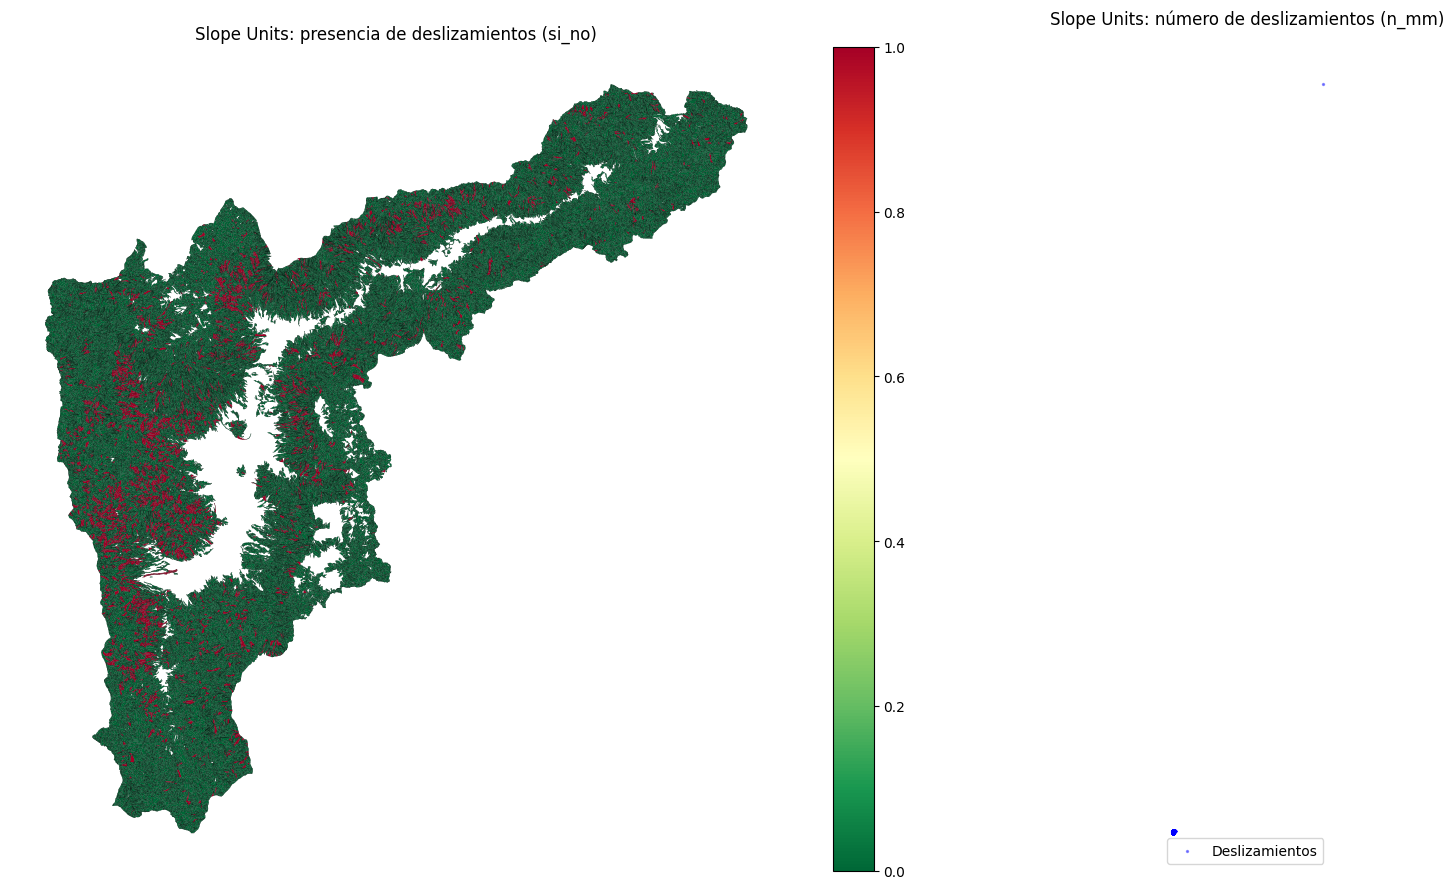

In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Mapa 1: si_no
slope_units_out.plot(
    column='si_no', ax=axes[0], legend=True,
    cmap='RdYlGn_r', edgecolor='black', linewidth=0.1
)
axes[0].set_title('Slope Units: presencia de deslizamientos (si_no)')
axes[0].set_axis_off()

# Mapa 2: n_mm
slope_units_out.plot(
    column='n_mm', ax=axes[1], legend=True,
    cmap='Reds', edgecolor='black', linewidth=0.1,
    scheme='NaturalBreaks', k=5
)
inventario.plot(ax=axes[1], color='blue', markersize=2, alpha=0.4, label='Deslizamientos')
axes[1].set_title('Slope Units: número de deslizamientos (n_mm)')
axes[1].set_axis_off()
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## **RECODIFICAR TIPOS DE SUELOS**

In [29]:
print(len(slope_units_out["Granulomet"].unique()))
slope_units_out["Granulomet"].unique()

17


array(['Arena arcillosa', 'Bloques, gravas, arenas y lodos',
       'Grava, arena y lodos', None, 'Arena, limo y grava',
       'Limo arenoso', 'Arena limosa', 'Limo arcilloso', 'Arena gravosa',
       'Arena limosa con gravas', 'Limo', 'Limo o arcilla arenosa',
       'Arena', 'Bloques, gravas y arenas', 'Arcilla y limo', 'Arcilla',
       'Arcilla limosa'], dtype=object)

In [30]:
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path

output_dir = Path("/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado")
output_path = output_dir / "slope_units_final_mm.gpkg"
output_layer = "slope_units_final_mm"

slope_units_out = gpd.read_file(output_path, layer=output_layer)



In [31]:
# ============================================================
# Unificación de Granulomet → columna simplificada 'suelos'
# ============================================================

# Diccionario de mapeo: categoría_nueva → [categorías_originales]
mapeo_suelos = {
    "Bloques, gravas, arenas y lodos": [
        "Bloques, gravas, arenas y lodos",
        "Grava, arena y lodos",
        "Arena, limo y grava",
        "Arena gravosa",
        "Arena limosa con gravas",
        "Bloques, gravas y arenas",
        "Arena"
    ],
    "Areno-arcilloso": ["Arena arcillosa"],
    "Areno-limoso":    ["Limo arenoso", "Arena limosa"],
    # "Limo o arcilla arenosa" se asigna aquí por defecto.
    # Si la quieres en "Areno-limoso", muévela de lista.
    "Limo-arcilloso":  ["Limo arcilloso", "Limo o arcilla arenosa",
                        "Arcilla y limo", "Arcilla limosa", "Arcilla", "Limo"],
}

# Invertir el diccionario: original → nueva
inv_mapeo = {orig: nueva for nueva, origs in mapeo_suelos.items() for orig in origs}

# Aplicar el mapeo; los None o valores no listados se agrupan en "Bloques, gravas, arenas y lodos"
# (porque así lo pediste: None entra en esa categoría)
slope_units_out["suelos"] = (
    slope_units_out["Granulomet"]
    .map(inv_mapeo)
    .fillna("Bloques, gravas, arenas y lodos")
)

# ---- Verificación ----
print("Conteo por categoría simplificada 'suelos':")
print(slope_units_out["suelos"].value_counts(dropna=False))

print("\nTabla cruzada Granulomet → suelos (para validar el mapeo):")
tabla = pd.crosstab(
    slope_units_out["Granulomet"].fillna("(None)"),
    slope_units_out["suelos"],
    margins=True,
)
print(tabla)

# Detectar categorías originales que no fueron mapeadas (deberían ser 0)
originales_unicas = set(slope_units_out["Granulomet"].dropna().unique())
no_mapeadas = originales_unicas - set(inv_mapeo.keys())
if no_mapeadas:
    print(f"\n⚠️  Categorías originales NO previstas en el mapeo: {no_mapeadas}")
    print("    (Quedaron agrupadas en 'Bloques, gravas, arenas y lodos' por el fillna.)")
else:
    print("\n✅ Todas las categorías originales están explícitamente mapeadas.")

Conteo por categoría simplificada 'suelos':
suelos
Areno-limoso                       23438
Areno-arcilloso                    17161
Bloques, gravas, arenas y lodos    11755
Limo-arcilloso                      8888
Name: count, dtype: int64

Tabla cruzada Granulomet → suelos (para validar el mapeo):
suelos                           Areno-arcilloso  Areno-limoso  \
Granulomet                                                       
(None)                                         0             0   
Arcilla                                        0             0   
Arcilla limosa                                 0             0   
Arcilla y limo                                 0             0   
Arena                                          0             0   
Arena arcillosa                            17161             0   
Arena gravosa                                  0             0   
Arena limosa                                   0         13327   
Arena limosa con gravas                

In [32]:
slope_units_out.to_file(output_path, layer=output_layer, driver='GPKG')
print(f"✅ Guardado en:\n   {output_path}")
print(f"   Capa: {output_layer}")
print(f"   Registros: {len(slope_units_out)}")

✅ Guardado en:
   /home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_final_mm.gpkg
   Capa: slope_units_final_mm
   Registros: 61242


## **AGREGAR CLUSTER DE LLUVIA**

In [34]:
import geopandas as gpd
import pandas as pd
import numpy as np

# Ruta de la capa de clusters de lluvia
clusters_path = "/home/oisanchezp/BACK_PAPER_RainfallLandslides_Vdea copy/DATA/shape_files/clusters.shp"

# Cargar e inspeccionar
clusters = gpd.read_file(clusters_path)
print(f"Clusters cargados: {len(clusters)}")
print(f"CRS: {clusters.crs}")
print(f"Columnas: {list(clusters.columns)}")
clusters.head()

Clusters cargados: 5
CRS: EPSG:4326
Columnas: ['NOMBRE', 'AREA_m2', 'PERIMETRO_', 'Cluster', 'geometry']


,NOMBRE,AREA_m2,PERIMETRO_,Cluster,geometry
0,Norte,2.062969e+08,82614.894347,2,"POLYGON ((-75.57108 6.27049, -75.57108 6.27049..."
1,Occidente,3.754912e+08,108927.952274,5,"POLYGON ((-75.66587 6.37006, -75.66583 6.36966..."
2,Sur,1.347485e+08,57144.130934,3,"POLYGON ((-75.65024 6.20830, -75.64974 6.20823..."
3,Oriente,3.754912e+08,108927.952274,1,"POLYGON ((-75.49966 6.28842, -75.49943 6.28834..."
4,Sap,3.754912e+08,108927.952274,4,"POLYGON ((-75.70778 6.25826, -75.70706 6.25870..."


In [35]:
# ⚠️ AJUSTA este nombre con la columna real que identifica la zona de lluvia
COL_ZONA = "Cluster"   # cambia si en tu shapefile se llama diferente

# Homogeneizar CRS
if clusters.crs != slope_units_out.crs:
    print(f"Reproyectando clusters {clusters.crs} → {slope_units_out.crs}")
    clusters = clusters.to_crs(slope_units_out.crs)

# Limpiar geometrías por si acaso
clusters["geometry"] = clusters.buffer(0)

# Asegurar su_id
if "su_id" not in slope_units_out.columns:
    slope_units_out = slope_units_out.reset_index(drop=True)
    slope_units_out["su_id"] = slope_units_out.index.astype(int)

# Overlay intersección
print("Calculando intersección slope_units ∩ clusters ...")
inter = gpd.overlay(
    slope_units_out[["su_id", "geometry"]],
    clusters[[COL_ZONA, "geometry"]],
    how="intersection",
    keep_geom_type=True,
)
inter["area_int"] = inter.geometry.area

# Zona dominante por slope unit (la que cubre más área)
idx_max = inter.groupby("su_id")["area_int"].idxmax()
zonas = (
    inter.loc[idx_max, ["su_id", COL_ZONA]]
    .rename(columns={COL_ZONA: "zona_lluvia"})
    .reset_index(drop=True)
)

# Unir a la capa principal
slope_units_out = slope_units_out.merge(zonas, on="su_id", how="left")

print(f"\n✅ Asignación completada")
print(f"Slope units con zona_lluvia: {slope_units_out['zona_lluvia'].notna().sum()} / {len(slope_units_out)}")
print(f"\nDistribución por zona:")
print(slope_units_out["zona_lluvia"].value_counts(dropna=False))

Reproyectando clusters EPSG:4326 → EPSG:3116
Calculando intersección slope_units ∩ clusters ...

✅ Asignación completada
Slope units con zona_lluvia: 60951 / 61242

Distribución por zona:
zona_lluvia
2.0    29701
3.0    14383
5.0     8490
1.0     5771
4.0     2606
NaN      291
Name: count, dtype: int64


In [36]:
cols_a_eliminar = [
    "cluster_prob",
    "area_dominante_m2",
    "area_total_su_m2",
    "pct_dominante",
    "n_pix_dominante",
    "n_pix_total",
    "pct_cobertura_dominante",
]

# Eliminar solo las que existan (evita KeyError si alguna ya no está)
existentes = [c for c in cols_a_eliminar if c in slope_units_out.columns]
slope_units_out = slope_units_out.drop(columns=existentes)

print(f"Columnas eliminadas: {existentes}")
print(f"Columnas finales ({len(slope_units_out.columns)}):")
print(list(slope_units_out.columns))

Columnas eliminadas: ['cluster_prob', 'area_dominante_m2', 'area_total_su_m2', 'pct_dominante', 'n_pix_dominante', 'n_pix_total', 'pct_cobertura_dominante']
Columnas finales (26):
['Id', 'gridcode', 'Shape_Leng', 'Shape_Area', 'slope_mean', 'curva_mean', 'acos_mean', 'asin_mean', 'aspect_mea', 'area', 'su_type', 'su_id', 'Codigo', 'Unidad_geo', 'Granulomet', 'Espesor_m', 'Gamma_kNm3', 'C_kPa', 'Phi', 'cobertura_cat', 'cobertura', 'n_mm', 'si_no', 'geometry', 'suelos', 'zona_lluvia']


In [37]:
from pathlib import Path

output_dir = Path("/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado")
output_path = output_dir / "slope_units_final_mm.gpkg"
output_layer = "slope_units_final_mm"

slope_units_out.to_file(output_path, layer=output_layer, driver="GPKG")
print(f"✅ Guardado: {output_path}")

✅ Guardado: /home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_final_mm.gpkg



=== suelos (km²) ===
suelos
Areno-limoso                       387.57
Areno-arcilloso                    289.20
Bloques, gravas, arenas y lodos    179.86
Limo-arcilloso                     150.35
Name: area_km2, dtype: float64

=== cobertura_cat (km²) ===
cobertura_cat
3.0    448.40
2.0    296.68
1.0    189.90
0.0     62.43
4.0      6.88
NaN      2.68
Name: area_km2, dtype: float64

=== su_type (km²) ===
su_type
3    574.52
1    384.87
2     47.59
Name: area_km2, dtype: float64


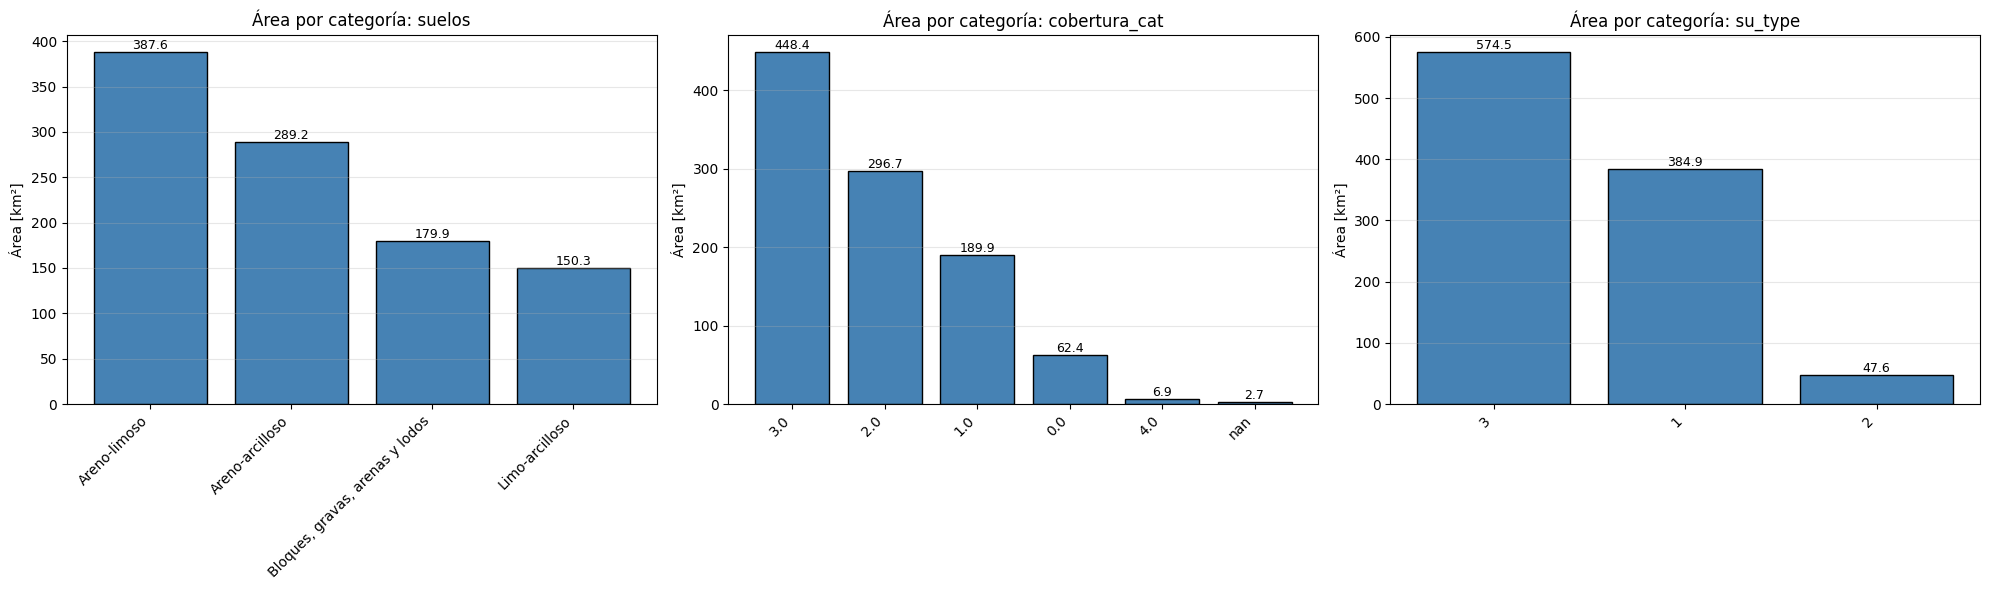

In [38]:
import matplotlib.pyplot as plt

# Calcular área en km² por slope unit (asumiendo CRS proyectado en metros)
if slope_units_out.crs.is_geographic:
    print("⚠️  CRS geográfico detectado. Reproyectando temporalmente a EPSG:3116 para calcular áreas.")
    su_area = slope_units_out.to_crs("EPSG:3116").copy()
else:
    su_area = slope_units_out.copy()

su_area["area_km2"] = su_area.geometry.area / 1e6

# Variables a graficar
variables = ["suelos", "cobertura_cat", "su_type"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, var in zip(axes, variables):
    if var not in su_area.columns:
        ax.set_title(f"'{var}' no está en la capa")
        ax.axis("off")
        continue

    # Sumar área por categoría y ordenar descendente
    resumen = (
        su_area.groupby(var, dropna=False)["area_km2"]
        .sum()
        .sort_values(ascending=False)
    )

    bars = ax.bar(
        range(len(resumen)),
        resumen.values,
        color="steelblue",
        edgecolor="black",
    )
    ax.set_xticks(range(len(resumen)))
    ax.set_xticklabels([str(x) for x in resumen.index], rotation=45, ha="right")
    ax.set_ylabel("Área [km²]")
    ax.set_title(f"Área por categoría: {var}")
    ax.grid(axis="y", alpha=0.3)

    # Etiquetas encima de cada barra
    for bar, val in zip(bars, resumen.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.1f}",
            ha="center", va="bottom", fontsize=9,
        )

    # Guardar también la tabla numérica
    print(f"\n=== {var} (km²) ===")
    print(resumen.round(2))

plt.tight_layout()
plt.savefig(output_dir / "area_por_categoria.png", dpi=200, bbox_inches="tight")
plt.show()

# ARREGLA CLASES DE COBERTURAS

In [ ]:
"""
Modificación de coberturas en slope_units_final.gpkg
- Fusiona "Aguas continentales" en "Bosques"
- Renombra clases textuales con etiquetas físicas
- Genera archivo nuevo (no sobrescribe el original)
"""

from pathlib import Path
import geopandas as gpd
import pandas as pd

# ---------------------------------------------------------------
# CONFIGURACIÓN
# ---------------------------------------------------------------
RUTA_ENTRADA = Path("/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_final.gpkg")
RUTA_SALIDA  = Path("/home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_final.gpkg")
NOMBRE_LAYER = "slope_units_final"


def inspeccionar(gdf: gpd.GeoDataFrame) -> None:
    """Imprime el estado actual de las dos columnas de cobertura."""
    print("=" * 60)
    print("INSPECCIÓN — estado actual")
    print("=" * 60)
    print(f"\nTotal de filas: {len(gdf)}")

    print("\nValores únicos en 'cobertura_cat' (numérica):")
    print(gdf["cobertura_cat"].value_counts(dropna=False).sort_index())

    print("\nValores únicos en 'cobertura' (texto):")
    print(gdf["cobertura"].value_counts(dropna=False).sort_index())

    print("\nMapeo actual cobertura_cat ↔ cobertura:")
    print(
        gdf.groupby(["cobertura_cat", "cobertura"], dropna=False)
        .size()
        .rename("n_SU")
        .reset_index()
    )
    print()


def transformar_coberturas(
    gdf: gpd.GeoDataFrame,
    codigo_aguas: int,
    codigo_bosques: int,
) -> gpd.GeoDataFrame:
    """
    Aplica las dos modificaciones:
    1) Fusiona el código de Aguas continentales en Bosques (en cobertura_cat).
    2) Reasigna etiquetas físicas en la columna cobertura.

    Parameters
    ----------
    gdf : GeoDataFrame de entrada (no se modifica in-place)
    codigo_aguas : código numérico actual de Aguas continentales
    codigo_bosques : código numérico actual de Bosques

    Returns
    -------
    GeoDataFrame transformado.
    """
    g = gdf.copy()

    # 1) Fusión Aguas → Bosques en la columna numérica
    n_fusionadas = (g["cobertura_cat"] == codigo_aguas).sum()
    g.loc[g["cobertura_cat"] == codigo_aguas, "cobertura_cat"] = codigo_bosques
    print(f"→ Fusionadas {n_fusionadas} SUs de Aguas (código {codigo_aguas}) "
          f"en Bosques (código {codigo_bosques}).")

    # 2) Reasignación de etiquetas físicas
    #    Mapeo definitivo según los códigos numéricos finales
    nuevo_mapeo = {
        0: "Tejido urbano continuo",
        1: "Tejido urbano discontinuo",
        2: "Territorios agrícolas",
        3: "Bosques",                       # incluye Aguas continentales fusionadas
        4: "Tierras desnudas y degradadas",
    }
    # Si tu código original era distinto, edita el dict arriba antes de correr.

    g["cobertura"] = g["cobertura_cat"].map(nuevo_mapeo)

    # Validación: que no queden NaN tras el remapeo
    n_nan = g["cobertura"].isna().sum()
    if n_nan > 0:
        codigos_huerfanos = (
            g.loc[g["cobertura"].isna(), "cobertura_cat"].unique()
        )
        raise ValueError(
            f"Quedaron {n_nan} SUs sin etiqueta. "
            f"Códigos sin mapear: {codigos_huerfanos}. "
            "Edita el diccionario 'nuevo_mapeo' antes de continuar."
        )

    return g


def main() -> None:
    if not RUTA_ENTRADA.exists():
        raise FileNotFoundError(f"No encuentro {RUTA_ENTRADA.resolve()}")

    print(f"Leyendo: {RUTA_ENTRADA}")
    gdf = gpd.read_file(RUTA_ENTRADA, layer=NOMBRE_LAYER)
    print(f"CRS: {gdf.crs}")

    # PASO 1 — Inspección obligatoria antes de modificar nada
    inspeccionar(gdf)

    # PASO 2 — Modificar SOLO si los códigos coinciden con tu expectativa
    #          (descomenta y ajusta los códigos según lo que muestre la inspección)
    
    gdf_v2 = transformar_coberturas(
        gdf,
        codigo_aguas=4,     # ← ajustar según inspección
        codigo_bosques=3,   # ← ajustar según inspección
    )
    
    # PASO 3 — Verificación post-transformación
    print("\n" + "=" * 60)
    print("VERIFICACIÓN — estado después de la transformación")
    print("=" * 60)
    inspeccionar(gdf_v2)

    # PASO 4 — Guardar nuevo archivo (no sobrescribe el original)
    gdf_v2.to_file(RUTA_SALIDA, layer=NOMBRE_LAYER, driver="GPKG")
    print(f"\n✓ Guardado en: {RUTA_SALIDA.resolve()}")


if __name__ == "__main__":
    main()

Leyendo: /home/oisanchezp/Thesis/src/04_Chapter/Slope_detallado/slope_units_final.gpkg
CRS: EPSG:3116
INSPECCIÓN — estado actual

Total de filas: 61242

Valores únicos en 'cobertura_cat' (numérica):
cobertura_cat
0.0     3744
1.0    11824
2.0    17770
3.0    27190
4.0       30
5.0      437
NaN      247
Name: count, dtype: int64

Valores únicos en 'cobertura' (texto):
cobertura
Clase_0     3744
Clase_1    11824
Clase_2    17770
Clase_3    27190
Clase_4       30
Clase_5      437
None         247
Name: count, dtype: int64

Mapeo actual cobertura_cat ↔ cobertura:
   cobertura_cat cobertura   n_SU
0            0.0   Clase_0   3744
1            1.0   Clase_1  11824
2            2.0   Clase_2  17770
3            3.0   Clase_3  27190
4            4.0   Clase_4     30
5            5.0   Clase_5    437
6            NaN       NaN    247

→ Fusionadas 30 SUs de Aguas (código 4) en Bosques (código 3).


ValueError: Quedaron 247 SUs sin etiqueta. Códigos sin mapear: [nan]. Edita el diccionario 'nuevo_mapeo' antes de continuar.